Need to generate code that takes an original chain, and a new chain. Need to oversamlple the chain so that it matches the dimensions of the original chain, to allow for better comparison 

In [1]:

import numpy as np

def match_chain_lengths(chain_coords, chain):

    n = chain_coords.shape[0]
    m = chain.shape[0]

    q = n // m #How many subdivisions are needed of each pair in chain
    r = n % m # how many extra subdivisions are needed

    coords = []

    for i in range(m-r):
        start = chain[i][1]
        end = chain[i][2]
        n_subdiv = q + (1 if i < r else 0)
        steps = np.linspace(0, 1, n_subdiv + 1)
        
        for s in range(n_subdiv):
            p1 = start + (end - start) * steps[s]
            p2 = start + (end - start) * steps[s + 1]
            coords.append([p1, p2])

    coords = np.array(coords)
    return torch.tensor(coords, dtype=torch.float32)

    


In [7]:
from graph_utils import create_mst_chain_from_coords, soft_mst_approximation2, convert_to_chain_format, match_chain_lengths, get_all_edges, cluster_spring_layout


import torch
import numpy as np

n = 1000
d = 1000

adj = torch.zeros(n,n, dtype = torch.float32)

for i in range(n):
    for j in range(n):
        if i <= j:
            adj[i][j] = 1

x = torch.zeros(n, d, dtype = torch.float32)

for i in range(n):
    for j in range(d):
        x[i][j] = 5 * np.random.randn() + 100



In [2]:
from models import DirectedDiffPool

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/torch_scatter/_version_cpu.so, 0x0006): Symbol not found: (__ZN5torch3jit17parseSchemaOrNameERKNSt3__112basic_stringIcNS1_11char_traitsIcEENS1_9allocatorIcEEEE)
  Referenced from: '/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/torch_scatter/_version_cpu.so'
  Expected in: '/opt/miniconda3/envs/traveler/lib/libtorch_cpu.dylib'
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/torch_cluster/_version_cpu.so, 0x0006): Symbol not found: (__ZN5torch3jit17parseSche

In [51]:

model = DirectedDiffPool(num_features=x.size(1), max_nodes=x.size(0))
x_out, adj_out = model(x, adj)

In [52]:
adj_out

tensor([[29696.2852, 17645.4355, 29024.5078, 25655.1484],
        [35216.2891, 23534.3672, 34792.0664, 34422.6523],
        [31635.7617, 19201.5137, 30978.9668, 27700.3477],
        [45244.3906, 28702.5684, 44716.6250, 42333.1172]],
       grad_fn=<MmBackward0>)

In [41]:
differences = []

n = adj_out.shape[0]
for i in range(n):
    for j in range(n):
        if i <= j:
            differences.append((adj_out[i][j] - adj_out[j][i]).detach().cpu().numpy())

differences = np.array(differences)

print(differences.mean())
print(differences.std())

-959.24475
8160.8916


In [53]:
torch.abs(adj_out - adj_out.T).mean().item()

9762.283203125

In [4]:
from models import DiffPool

model = DiffPool(num_features=x.size(1), max_nodes=x.size(0))
x_out, adj_out = model(x, adj)

In [ ]:
model = DiffPool(num_features=x.size(1), max_nodes=x.size(0))
x_out, adj_out = model(x, adj)
torch.abs(adj_out - adj_out.T).mean().item()

5964.06640625

In [44]:
differences = []

n = adj_out.shape[0]
for i in range(n):
    for j in range(n):
        if i <= j:
            differences.append((adj_out[i][j] - adj_out[j][i]).detach().cpu().numpy())

differences = np.array(differences)

print(differences.mean())
print(differences.std())

3291.5347
8688.877


In [41]:
chain = soft_mst_approximation2(x_out)

print(chain.shape)

torch.Size([6, 2, 2])


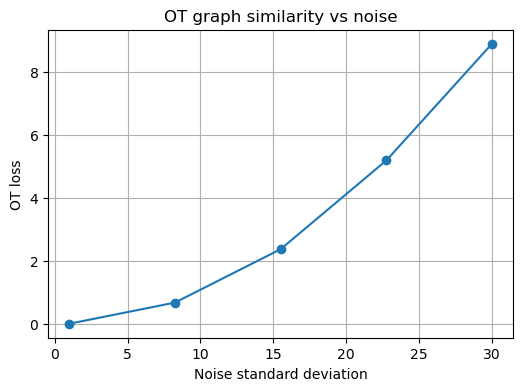

In [6]:
from graph_utils import OT_graph_similarity
import matplotlib.pyplot as plt

losses = []

n = 1000
d = 10
P = torch.eye(n)
x = torch.zeros(n,d, dtype = torch.float32)

for i in range(n):
    for j in range(d):
        x[i][j] = 100

y = torch.zeros(n,d, dtype = torch.float32)

stds = np.linspace(1, 30, 5)
for std in stds:
    for i in range(n):
        for j in range(d):
            y[i][j] = x[i][j] + std * np.random.randn()
    
    losses.append(OT_graph_similarity(x, y, P))

# Plot
plt.figure(figsize=(6,4))
plt.plot(stds, losses, marker='o')
plt.xlabel("Noise standard deviation")
plt.ylabel("OT loss")
plt.title("OT graph similarity vs noise")
plt.grid(True)
plt.show()



Testing directed diffpool deals with assymetry better

In [7]:
from dataset import preprocess_pancreas_data
FILE_NAME = "data/pancreas.h5ad"
adata_subsampled, x, adj = preprocess_pancreas_data(FILE_NAME)

Filtered out 22142 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [5]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

0.0
0.25
0.5
0.75
1.0


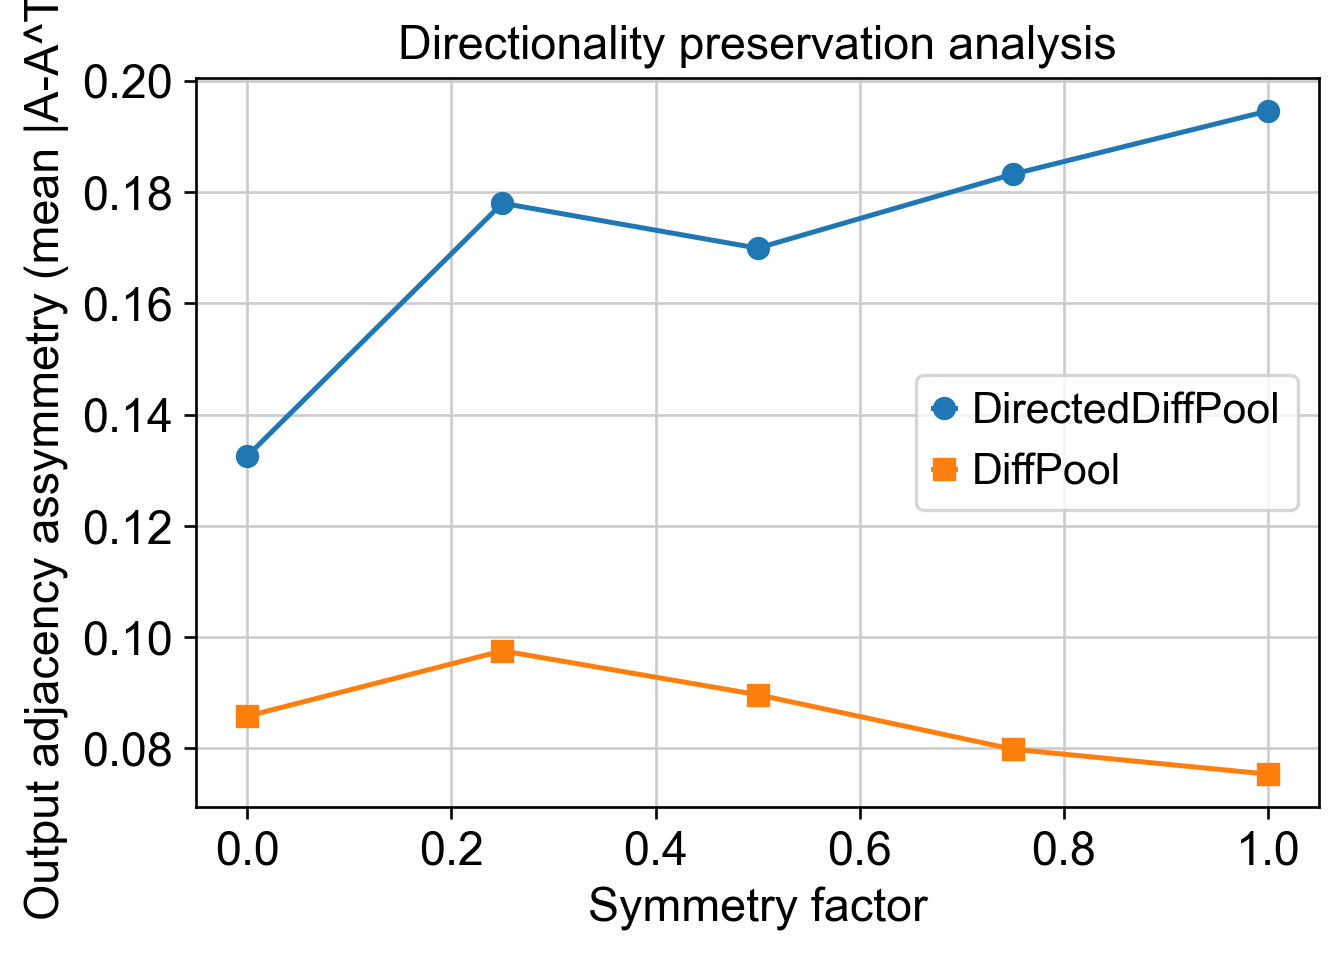

In [9]:
from models import DiffPool, DirectedDiffPool
import numpy as np
import torch
import matplotlib.pyplot as plt



# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

symmetries = np.linspace(0, 1, 5)   # fraction of edges that are symmetric

set_seed()
non_directed = DiffPool(num_features=y.size(1), max_nodes=y.size(0))
non_directed.reset_parameters()
directed = DirectedDiffPool(num_features=y.size(1), max_nodes=y.size(0))
set_seed()
directed.reset_parameters()
directeds = []
nondirecteds = [] 
for symmetry in symmetries:
    print(symmetry)
    directed_list = []
    nondirected_list = []
    for k in range(5):
        adj_clone = adj.clone()
        # Control symmetry
        for i in range(n):
            for j in range(i+1, n):
                if np.random.rand() < symmetry:
                    # Mirror edge to make symmetric
                    adj_clone[j, i] = adj_clone[i, j]
                # else leave it as is (asymmetric)

        _, adj_undirected = non_directed(y, adj_clone)
        _, adj_directed = directed(y, adj_clone)
        directed_list.append(torch.abs(adj_directed - adj_directed.T).mean().item())
        nondirected_list.append(torch.abs(adj_undirected - adj_undirected.T).mean().item())

    directed_list =np.array(directed_list)
    nondirected_list =np.array(nondirected_list)
    directeds.append(directed_list.mean())
    nondirecteds.append(nondirected_list.mean())

plt.figure(figsize=(6, 4))

# Plot DirectedDiffPool
plt.plot(symmetries, directeds, marker='o', label='DirectedDiffPool')

# Plot DiffPool
plt.plot(symmetries, nondirecteds, marker='s', label='DiffPool')

plt.xlabel("Symmetry factor")
plt.ylabel("Output adjacency assymmetry (mean |A-A^T|)")
plt.title("Directionality preservation analysis")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
torch.abs(adj - adj.T).mean().item()

0.013172073289752007

In [4]:
def get_all_edges(x_out, adj_out):
    edge_list = []
    for i in range(adj_out.shape[0]):
        for j in range(i+1, adj_out.shape[0]):  # Only upper triangle to avoid duplicates
            edge_list.append((i, j))
    
    chain = torch.zeros((len(edge_list), 2, x_out.shape[1]), device=x_out.device)
    for idx, (i, j) in enumerate(edge_list):
        chain[idx, 0] = x_out[i]
        chain[idx, 1] = x_out[j]

    weights = torch.zeros(len(edge_list), device=x_out.device) 
    for idx, (i, j) in enumerate(edge_list):
        weights[idx] = adj_out[i][j]
    return chain, weights

In [12]:

from neural_k_forms.chains import generate_integration_matrix
from neural_k_forms.forms import NeuralOneForm
import torch.nn as nn

c = 1

# Initialize neural vector field
vf_in = nn.Sequential(
    nn.Conv1d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv1d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv1d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64 * 2, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2 * c)
)

vf = NeuralOneForm(vf_in, input_dim=None, hidden_dim=None, num_cochains=c)

n = 1000
d = 1000

adj = torch.zeros(n,n, dtype = torch.float32)

for i in range(n):
    for j in range(n):
        if i <= j:
            adj[i][j] = 1

x = torch.zeros(n, d, dtype = torch.float32)

for i in range(n):
    for j in range(d):
        x[i][j] = 5 * np.random.randn() + 100

directed = DirectedDiffPool(num_features=x.size(1), max_nodes=x.size(0))
x_out, adj_out = directed(x, adj)

chain, weights = get_all_edges(x_out, adj_out)
X = generate_integration_matrix(vf, chain)
X = X.squeeze() * weights.squeeze()



DEBUG - NeuralOneForm input shape: torch.Size([6, 5, 2])
tensor([[ 0.3079],
        [-1.4634],
        [-0.0638],
        [-1.8561],
        [-0.3670],
        [ 1.4105]], grad_fn=<SumBackward1>)
tensor([ 0.0810, -0.3913, -0.0170, -0.5335, -0.1000,  0.3240],
       grad_fn=<MulBackward0>)
tensor([0.2632, 0.2674, 0.2672, 0.2874, 0.2724, 0.2297], grad_fn=<CopySlices>)
6


Checking the OT method works on coarsened graph outputs

In [3]:
def OT_loss(node_embeddings, x_out, P):
    N = x_out.shape[0]
    # 1. Compute pairwise squared distances (cost matrix)
    C = torch.cdist(node_embeddings, x_out, p=2) ** 2
    # 2. Compute alignment loss
    return torch.sum(P * C) / N**2
  

Noise std: 0.0
Noise std: 0.2631578947368421
Noise std: 0.5263157894736842
Noise std: 0.7894736842105263
Noise std: 1.0526315789473684
Noise std: 1.3157894736842104
Noise std: 1.5789473684210527
Noise std: 1.8421052631578947
Noise std: 2.1052631578947367
Noise std: 2.3684210526315788
Noise std: 2.631578947368421
Noise std: 2.894736842105263
Noise std: 3.1578947368421053
Noise std: 3.4210526315789473
Noise std: 3.6842105263157894
Noise std: 3.9473684210526314
Noise std: 4.2105263157894735
Noise std: 4.473684210526316
Noise std: 4.7368421052631575
Noise std: 5.0


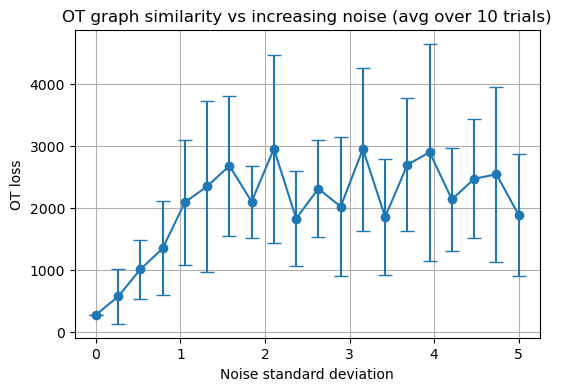

In [19]:

# --- Set seeds for reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
noise_levels = np.linspace(0, 5, 20)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for std in noise_levels:
    trial_losses = []
    print(f"Noise std: {std}")
    for _ in range(num_trials):
        x = y + std * torch.randn(n, d, dtype=torch.float32)

        # Coarsen x
        x_out, adj_out = model(x, adj)
        x_embeddings = model.compute_node_embeddings(x, adj, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj)

        # Compute OT loss between coarsened x and original coarsened y
        loss = OT_loss(y_embeddings, x_out, P_x)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(noise_levels, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("Noise standard deviation")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing noise (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

Swap prob: 0.0
Swap prob: 0.05263157894736842
Swap prob: 0.10526315789473684
Swap prob: 0.15789473684210525
Swap prob: 0.21052631578947367
Swap prob: 0.2631578947368421
Swap prob: 0.3157894736842105
Swap prob: 0.3684210526315789
Swap prob: 0.42105263157894735
Swap prob: 0.47368421052631576
Swap prob: 0.5263157894736842
Swap prob: 0.5789473684210527
Swap prob: 0.631578947368421
Swap prob: 0.6842105263157894
Swap prob: 0.7368421052631579
Swap prob: 0.7894736842105263
Swap prob: 0.8421052631578947
Swap prob: 0.894736842105263
Swap prob: 0.9473684210526315
Swap prob: 1.0


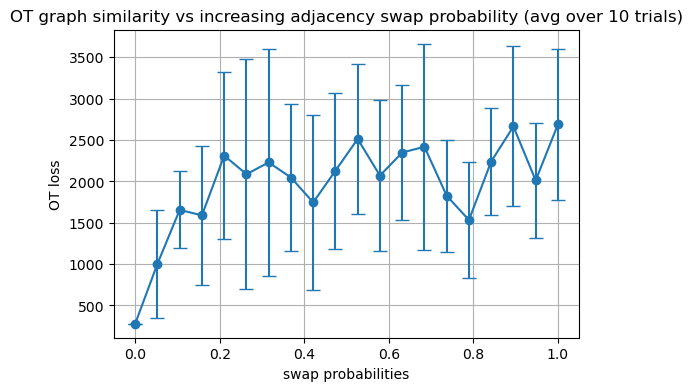

In [21]:

# --- Set seeds for reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
swap_probs = np.linspace(0, 1, 20)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for p in swap_probs:
    trial_losses = []
    print(f"Swap prob: {p}")
    for _ in range(num_trials):
        x = y
 
        # Mask of entries to resample
        mask = (torch.rand_like(adj) < p)

        # Resample: generate new values for mask positions
        new_values = torch.rand_like(adj)

        # Apply resampling
        adj_resampled = adj.clone()
        adj_resampled[mask] = new_values[mask]
        # Coarsen x
        x_out, adj_out = model(x, adj_resampled)
        x_embeddings = model.compute_node_embeddings(x, adj_resampled, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj_resampled)

        # Compute OT loss between coarsened x and original coarsened y
        loss = OT_loss(y_embeddings, x_out, P_x)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(swap_probs, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("swap probabilities")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing adjacency swap probability (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

Testing OT losses

Noise std: 0.0
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
Noise std: 0.25
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
torch.Size([4, 2])
torch.Size([1000, 4])
torch.Size([1000, 2])
to

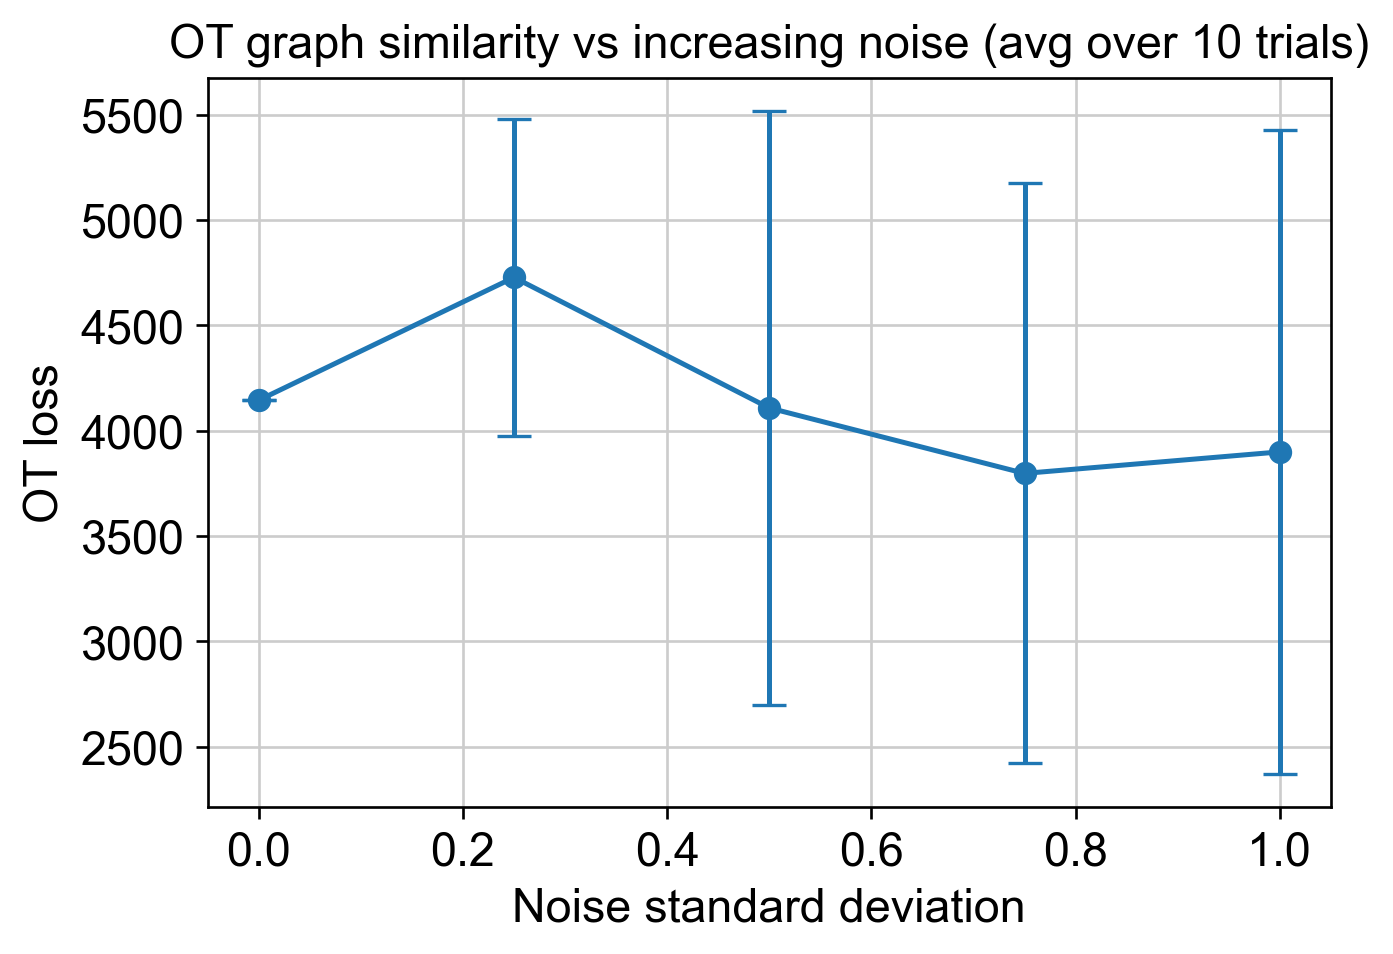

In [8]:

# --- Set seeds for reproducibility ---
set_seed()

# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
noise_levels = np.linspace(0, 1, 5)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)
model.reset_parameters()

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for std in noise_levels:
    trial_losses = []
    print(f"Noise std: {std}")
    for _ in range(num_trials):
        x = y + std * torch.randn(n, d, dtype=torch.float32)

        # Coarsen x
        x_out, adj_out = model(x, adj)
        x_embeddings = model.compute_node_embeddings(x, adj, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj)

        # Compute OT loss between coarsened x and original coarsened y
        print(y_embeddings.shape)
        print(x_out.shape)
        print(P_y.shape)
        loss = OT_loss(y_embeddings, x_out, P_y)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(noise_levels, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("Noise standard deviation")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing noise (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

In [4]:
import matplotlib.pyplot as plt

In [ ]:


# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(noise_levels, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("Noise standard deviation")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing noise (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

Swap prob: 0.0
Swap prob: 0.05263157894736842
Swap prob: 0.10526315789473684
Swap prob: 0.15789473684210525
Swap prob: 0.21052631578947367
Swap prob: 0.2631578947368421
Swap prob: 0.3157894736842105
Swap prob: 0.3684210526315789
Swap prob: 0.42105263157894735
Swap prob: 0.47368421052631576
Swap prob: 0.5263157894736842
Swap prob: 0.5789473684210527
Swap prob: 0.631578947368421
Swap prob: 0.6842105263157894
Swap prob: 0.7368421052631579
Swap prob: 0.7894736842105263
Swap prob: 0.8421052631578947
Swap prob: 0.894736842105263
Swap prob: 0.9473684210526315
Swap prob: 1.0


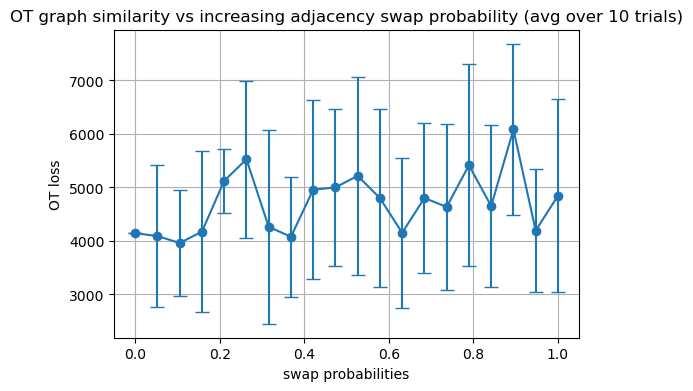

In [18]:
import matplotlib.pyplot as plt
# --- Set seeds for reproducibility ---
# torch.manual_seed(42)
# np.random.seed(42)
set_seed()
# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
swap_probs = np.linspace(0, 1, 20)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)
model.reset_parameters()

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for p in swap_probs:
    trial_losses = []
    print(f"Swap prob: {p}")
    for _ in range(num_trials):
        x = y
 
        # Mask of entries to resample
        mask = (torch.rand_like(adj) < p)

        # Resample: generate new values for mask positions
        new_values = torch.rand_like(adj)

        # Apply resampling
        adj_resampled = adj.clone()
        adj_resampled[mask] = new_values[mask]
        # Coarsen x
        x_out, adj_out = model(x, adj_resampled)
        x_embeddings = model.compute_node_embeddings(x, adj_resampled, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj_resampled)

        # Compute OT loss between coarsened x and original coarsened y
        loss = OT_loss(x_out, y_embeddings, P_y)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(swap_probs, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("swap probabilities")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing adjacency swap probability (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

In [6]:
def chamfer_loss(x, y):
    x = x.unsqueeze(1)
    y = y.unsqueeze(0)
    dist = ((x-y)**2).sum(-1)
    return dist.min(1)[0].mean() + dist.min(0)[0].mean()

Using Chamfer Loss instead of OT Loss

In [5]:
from main3 import set_seed

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/phate/__init__.py


In [ ]:
set_seed()

# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
noise_levels = np.linspace(0, 5, 20)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)
model.reset_parameters()

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for std in noise_levels:
    trial_losses = []
    print(f"Noise std: {std}")
    for _ in range(num_trials):
        x = y + std * torch.randn(n, d, dtype=torch.float32)

        # Coarsen x
        x_out, adj_out = model(x, adj)
        x_embeddings = model.compute_node_embeddings(x, adj, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj)

        # Compute OT loss between coarsened x and original coarsened y
        # loss = OT_loss(y_embeddings, x_out, P_y)

        #Chamfer loss
        loss = chamfer_loss(y_embeddings, x_out)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))



Noise std: 0.0
Noise std: 0.2631578947368421
Noise std: 0.5263157894736842
Noise std: 0.7894736842105263
Noise std: 1.0526315789473684
Noise std: 1.3157894736842104
Noise std: 1.5789473684210527
Noise std: 1.8421052631578947
Noise std: 2.1052631578947367
Noise std: 2.3684210526315788
Noise std: 2.631578947368421
Noise std: 2.894736842105263
Noise std: 3.1578947368421053
Noise std: 3.4210526315789473
Noise std: 3.6842105263157894
Noise std: 3.9473684210526314
Noise std: 4.2105263157894735
Noise std: 4.473684210526316
Noise std: 4.7368421052631575
Noise std: 5.0


NameError: name 'plt' is not defined

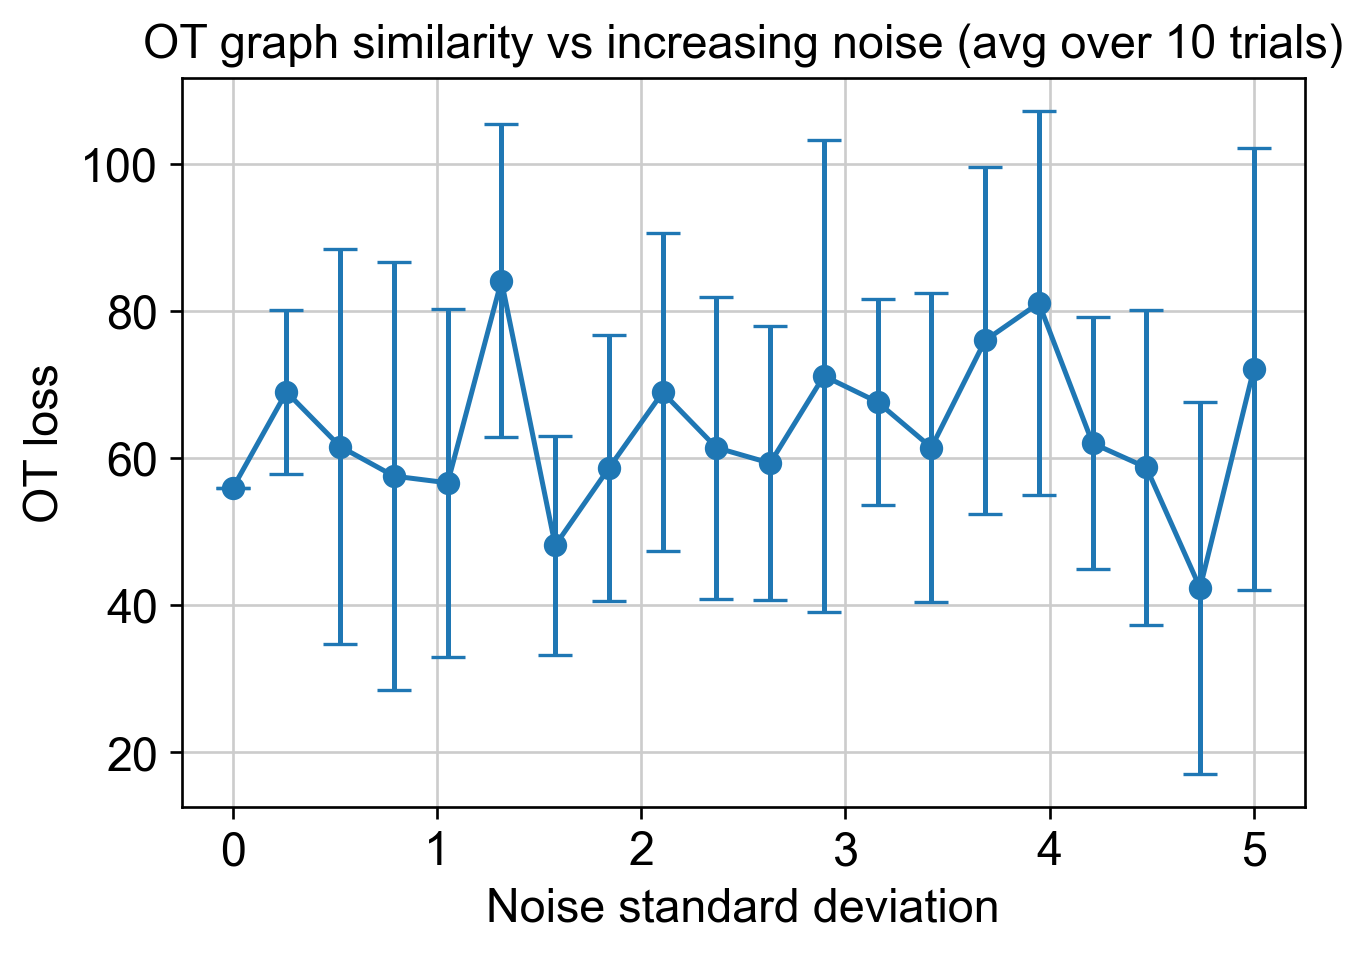

In [9]:
import matplotlib.pyplot as plt

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(noise_levels, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("Noise standard deviation")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing noise (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

Swap prob: 0.0
Swap prob: 0.05263157894736842
Swap prob: 0.10526315789473684
Swap prob: 0.15789473684210525
Swap prob: 0.21052631578947367
Swap prob: 0.2631578947368421
Swap prob: 0.3157894736842105
Swap prob: 0.3684210526315789
Swap prob: 0.42105263157894735
Swap prob: 0.47368421052631576
Swap prob: 0.5263157894736842
Swap prob: 0.5789473684210527
Swap prob: 0.631578947368421
Swap prob: 0.6842105263157894
Swap prob: 0.7368421052631579
Swap prob: 0.7894736842105263
Swap prob: 0.8421052631578947
Swap prob: 0.894736842105263
Swap prob: 0.9473684210526315
Swap prob: 1.0


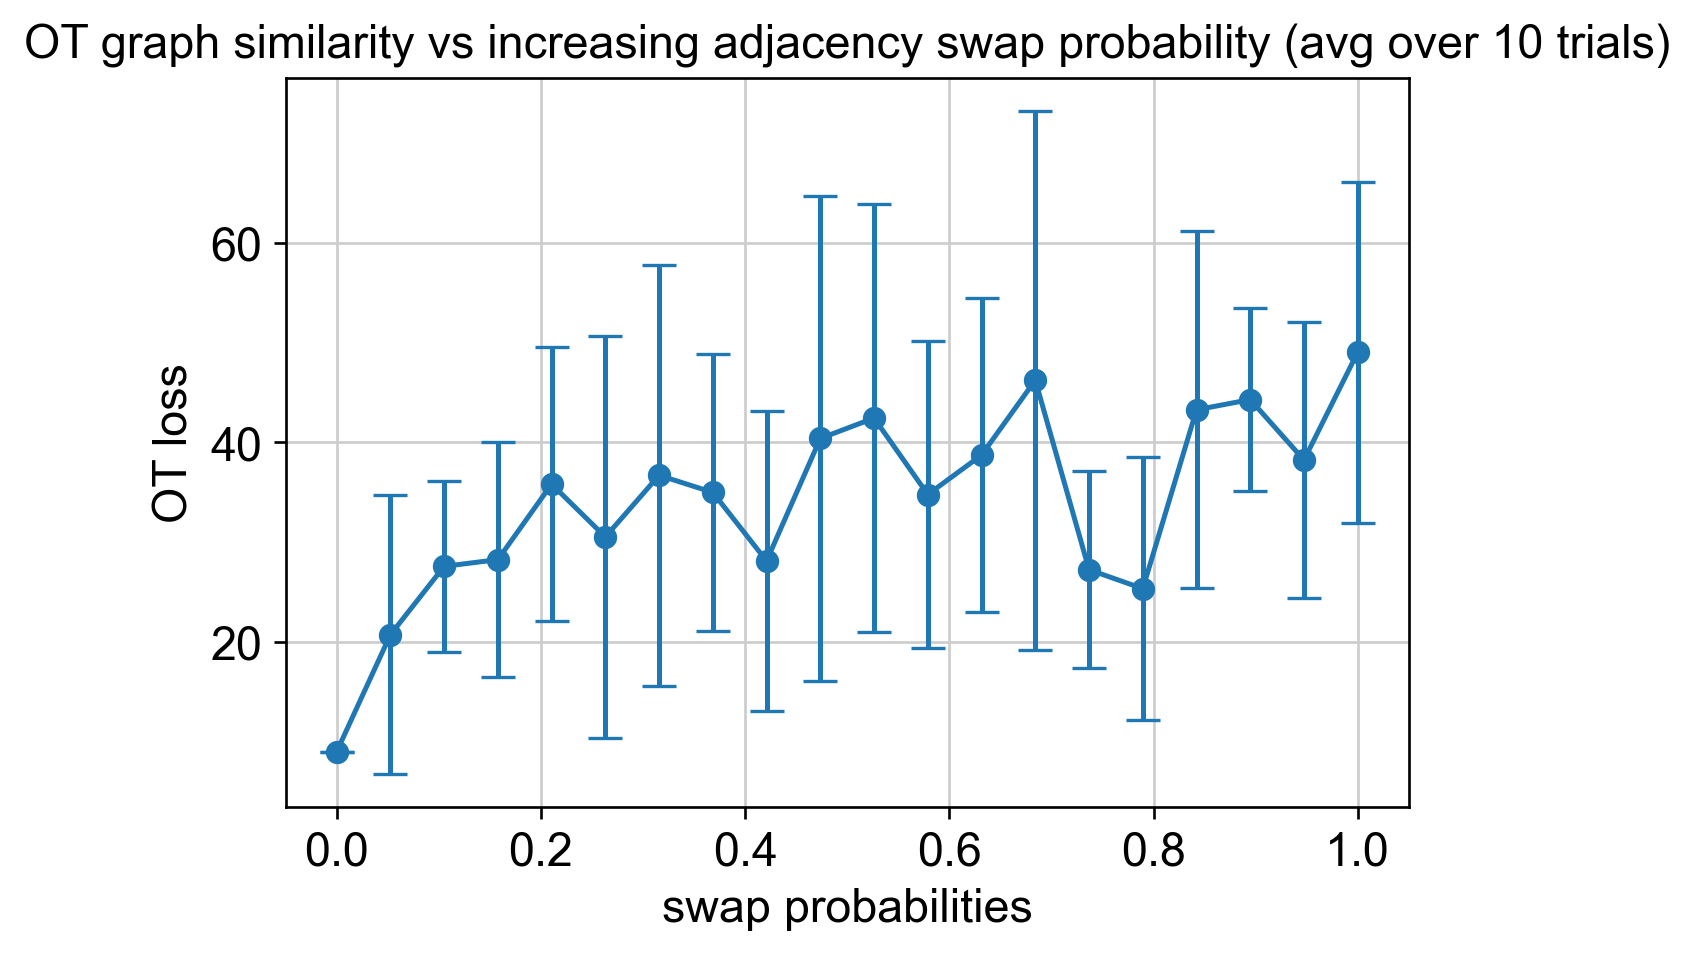

In [10]:

# --- Set seeds for reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

# --- Parameters ---
n = 1000        # number of nodes
d = 1000        # node features
swap_probs = np.linspace(0, 1, 20)  # noise scale for x
num_trials = 10   # number of repetitions per noise level

# --- Create adjacency matrix (vectorized) ---
adj = (torch.rand(n, n) < 0.1).float()
adj.fill_diagonal_(0)  # no self-loops

# --- Original node features ---
y = torch.randn(n, d, dtype=torch.float32)

# --- Initialize model ---
model = DirectedDiffPool(num_features=d, max_nodes=n)

# --- Coarsen original y ---
y_out, adj_out = model(y, adj)
y_embeddings = model.compute_node_embeddings(y, adj, full_hierarchy=True)
P_y = model.cluster_matrix(y, adj)


# --- Compute OT losses for x datasets with increasing noise ---
loss_means = []
loss_stds = []

for p in swap_probs:
    trial_losses = []
    print(f"Swap prob: {p}")
    for _ in range(num_trials):
        x = y
 
        # Mask of entries to resample
        mask = (torch.rand_like(adj) < p)

        # Resample: generate new values for mask positions
        new_values = torch.rand_like(adj)

        # Apply resampling
        adj_resampled = adj.clone()
        adj_resampled[mask] = new_values[mask]
        # Coarsen x
        x_out, adj_out = model(x, adj_resampled)
        x_embeddings = model.compute_node_embeddings(x, adj_resampled, full_hierarchy=True)
        P_x = model.cluster_matrix(x, adj_resampled)

        # Compute OT loss between coarsened x and original coarsened y
        # loss = OT_loss(y_embeddings, x_out, P_y)
        loss = chamfer_loss(y_embeddings, x_out)
        trial_losses.append(loss.item())

    # Aggregate
    loss_means.append(np.mean(trial_losses))
    loss_stds.append(np.std(trial_losses))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.errorbar(swap_probs, loss_means, yerr=loss_stds, marker='o', capsize=5)
plt.xlabel("swap probabilities")
plt.ylabel("OT loss")
plt.title(f"OT graph similarity vs increasing adjacency swap probability (avg over {num_trials} trials)")
plt.grid(True)
plt.show()

In [6]:
def OT_loss(x_out, node_embeddings, P):
    N = x_out.shape[0]
    # 1. Compute pairwise squared distances (cost matrix)
    C = torch.cdist(node_embeddings, x_out, p=2) ** 2
    # 2. Compute alignment loss
    
    return torch.sum(P * C) / N**2


In [ ]:
#In model initialisation

self.projection = nn.Sequential(
            nn.Linear(output_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
